<a href="https://colab.research.google.com/github/incable1560/MLF_228046_Ondrej_Hrozek/blob/main/MLF_Final_Project_O_Hrozek_O_Pulpit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torchvision import transforms
from torch import nn, optim
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt
from zipfile import ZipFile
from google.colab import drive
import copy
import numpy as np
import random

In [ ]:
drive.mount('/content/drive')

train_zip = '/content/drive/MyDrive/ML_project/x_train.zip'
test_zip = '/content/drive/MyDrive/ML_project/x_test.zip'

with ZipFile(train_zip, 'r') as zip_ref:
    zip_ref.extractall('/content/x_train')

with ZipFile(test_zip, 'r') as zip_ref:
    zip_ref.extractall('/content/x_test')

labels = pd.read_csv('/content/drive/MyDrive/ML_project/y_train_v2.csv')
labels = labels.sort_values(by=labels.columns[0]).reset_index(drop=True)

Mounted at /content/drive


### Reproducibility

This block ensures that all sources of randomness are controlled so that results are consistent across runs.

It sets fixed seeds for:
- PyTorch (CPU and GPU)
- NumPy
- Python's random module

This is important for debugging and fair comparison of experiments.

In [ ]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

set_seed(42)

### Custom Dataset (RadarDataset)

This class defines how data is loaded for training and testing.

Key features:
- Inherits from `torch.utils.data.Dataset`.
- Ensures correct ordering of files using numeric sorting.
- Converts images to RGB format.
- Applies transformations.

Output:
- Training: (image, label)
- Testing: (image, filename)

In [ ]:
class RadarDataset(torch.utils.data.Dataset):
    def __init__(self, folder, labels=None, transform=None):
        self.folder = folder
        self.transform = transform
        self.labels = labels
        self.files = sorted(
            os.listdir(folder),
            key=lambda x: int(x.split('_')[1].split('.')[0])
        )

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_name = self.files[idx]
        img_path = os.path.join(self.folder, img_name)

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        if self.labels is not None:
            img_id = int(img_name.split('_')[1].split('.')[0])
            label = self.labels.iloc[img_id - 1, 1]
            return image, label
        else:
            return image, img_name

### Data Transformations

Two transformation pipelines are defined:

#### Training Transform:
- Resize to 224×224
- Random horizontal flip
- Random rotation
- Normalize using ImageNet statistics

#### Validation/Test Transform:
- Resize to 224×224
- Normalize only

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

### Train/Validation Split

This block:
- Creates the full dataset using training data and transformations.
- Splits it into:
  - 80% training set
  - 20% validation set

DataLoaders are then created:
- Training loader: shuffled batches
- Validation loader: no shuffling

Batch size = 64

In [ ]:
full_dataset = RadarDataset('/content/x_train', labels, train_transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size]
)

val_dataset.dataset.transform = val_transform

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)


### Model Definition (EfficientNet-B0)

This block:
- Loads a pretrained EfficientNet-B0 model.
- Replaces the final classification layer to match the task (4 classes).

Custom classifier:
- Linear → 256 units
- ReLU activation
- Dropout (0.3) for regularization
- Final Linear → 4 output classes

Using a pretrained model (transfer learning) significantly improves performance and reduces training time.

In [ ]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

model.classifier[1] = nn.Sequential(
    nn.Linear(model.classifier[1].in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 4)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 142MB/s] 


### Training Setup

#### Loss Function:
- CrossEntropyLoss with label smoothing (0.1)
- Helps reduce overconfidence and improves generalization

#### Optimizer:
- Adam optimizer
- Learning rate = 1e-3
- Weight decay = 1e-4 (L2 regularization)

#### Learning Rate Scheduler:
- ReduceLROnPlateau
- Reduces learning rate when validation accuracy stops improving

#### Early Stopping:
- Stops training if validation accuracy does not improve for 4 epochs

Tracking:
- Training loss history
- Validation accuracy history
- Best model weights

In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2
)

epochs = 30

best_acc = 0
patience = 4
counter = 0
best_model_wts = copy.deepcopy(model.state_dict())

train_losses = []
val_accuracies = []

### Training Loop


#### Training Phase:
- Model set to training mode
- Forward pass → compute predictions
- Compute loss
- Backpropagation (loss.backward)
- Update weights (optimizer.step)

#### Validation Phase:
- Model set to evaluation mode
- No gradient computation
- Compute predictions
- Calculate validation accuracy

#### Scheduler:
- Adjusts learning rate based on validation accuracy

#### Early Stopping:
- Saves best model when accuracy improves
- Stops training if no improvement for several epochs

Finally, the best model weights are restored.

In [ ]:
for epoch in range(epochs):

    # TRAINING
    model.train()
    total_loss = 0

    for images, labels_batch in train_loader:
        images = images.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    epoch_loss = total_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # VALIDATION
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels_batch in val_loader:
            images = images.to(device)
            labels_batch = labels_batch.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels_batch).sum().item()
            total += labels_batch.size(0)

    accuracy = correct / total
    val_accuracies.append(accuracy)

    scheduler.step(accuracy)

    print(f"Epoch {epoch+1}: Loss={epoch_loss:.4f}, Val Acc={accuracy:.4f}")

    # EARLY STOPPING
    if accuracy > best_acc:
        best_acc = accuracy
        best_model_wts = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

# Load best model
model.load_state_dict(best_model_wts)

print(f"\nBest Validation Accuracy: {best_acc:.4f}")

Epoch 1: Loss=0.7732, Val Acc=0.8787
Epoch 2: Loss=0.5396, Val Acc=0.9345
Epoch 3: Loss=0.4795, Val Acc=0.9377
Epoch 4: Loss=0.4494, Val Acc=0.9453
Epoch 5: Loss=0.4226, Val Acc=0.9307
Epoch 6: Loss=0.4076, Val Acc=0.9166
Epoch 7: Loss=0.4025, Val Acc=0.9231
Epoch 8: Loss=0.3785, Val Acc=0.9534
Epoch 9: Loss=0.3628, Val Acc=0.9648
Epoch 10: Loss=0.3602, Val Acc=0.9599
Epoch 11: Loss=0.3605, Val Acc=0.9523
Epoch 12: Loss=0.3601, Val Acc=0.9518
Epoch 13: Loss=0.3581, Val Acc=0.9599
Early stopping triggered

Best Validation Accuracy: 0.9648


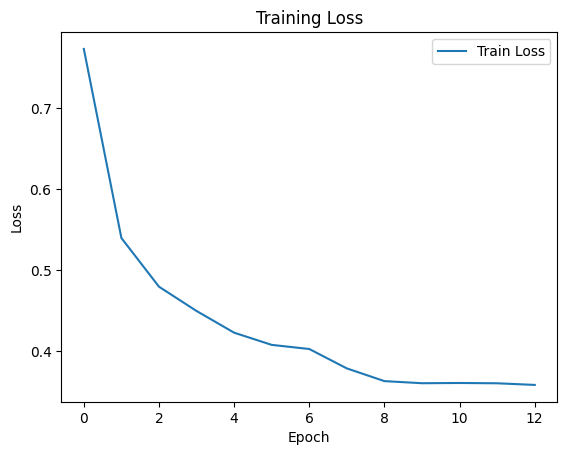

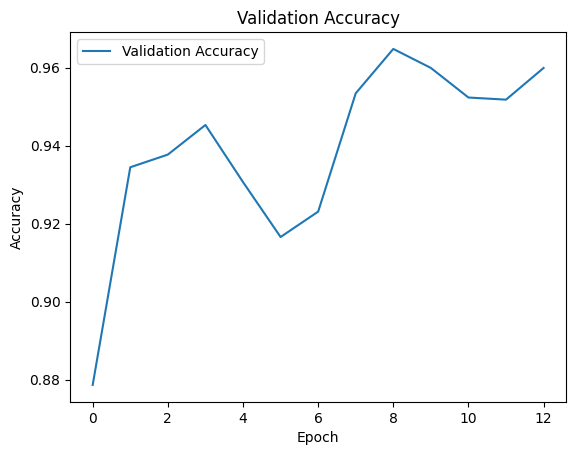

In [ ]:
plt.figure()
plt.plot(train_losses, label='Train Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()
plt.show()

### Test Prediction

This block:
- Loads the test dataset
- Runs inference using the trained model
- Computes predicted class for each image

Important:
- No gradients are computed
- Predictions and corresponding image IDs are stored

Image IDs are extracted from filenames to match submission format.

In [ ]:
test_dataset = RadarDataset('/content/x_test', transform=val_transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64)

model.eval()

predictions = []
ids = []

with torch.no_grad():
    for images, names in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        predictions.extend(preds.cpu().numpy())

        for name in names:
            img_id = int(name.split('_')[1].split('.')[0]) - 1
            ids.append(img_id)

In [ ]:
from google.colab import files

submission = pd.DataFrame({
    'id': ids,
    'target': predictions
})

submission.to_csv('submission.csv', index=False)
files.download('submission.csv')

print("Submission saved!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Submission saved!
